In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
data = {
    'CB_ Serial' : ['PR01049/A', 'PR01049/B', 'PR01049/C', 'PR01049/D',
                     'PR01049/E', 'PR01049/F', 'PR01049/G', 'PR01049/H',
                    'PR01049/J'],
    'Close_L1_ms': [65.1, 65.2, 65.5, 63.8, 63.4, 64.6, 65.1, 63.7, 63.1],
    'Close_L2_ms': [65.1, 65.4, 65.3, 63.8, 63.4, 64.7, 65.0, 63.9, 63.2],
    'Close_L3_ms': [65.2, 65.6, 65.5, 63.9, 63.5, 64.8, 65.2, 64.0, 63.1],
    'Open_L1_ms' : [43.8, 43.9, 43.3, 43.5, 43.4, 44.3, 43.8, 43.9,44.4],
    'Open_L2_ms' : [43.9, 43.8, 43.5, 43.5, 43.6, 44.0, 44.1, 44.0, 44.1],
    'Open_L3_ms'  : [43.9, 43.7, 43.5, 43.6, 43.5, 43.9, 44.1, 43.9, 44.3],
    'Simult_ms'  : [0.1, 0.4, 0.2, 0.1, 0.1, 0.2, 0.2, 0.3, 0.3, ],
    'CR_L1_uohm' : [49, 50, 48, 50, 49, 52, 49, 50, 51],
    'CR_L2_uohm' : [54, 51, 53, 51, 52, 51, 54, 51, 49],
    'CR_L3_uohm' : [50, 50, 51, 51, 50, 50, 50, 50, 51],
    'IR_Phase_Earth':['>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm'],
    'IR_Interruptor':['>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm', '>1TOhm'],
    'PD_Result' : ['OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK'],
}

df = pd.DataFrame(data)
print ("Evolis CB COMPLETE TEST ANALYSIS")
print (" Project : PR.01049")
print ("Customer : CONFIDENTIAL CUSTOMER")
print ("Engineer : MOHAMMED AZAM ALI")
print ("Company  : SCHNEIDER ELECTRIC")
print ("-"*55)
print (df.to_string(index=False))


Evolis CB COMPLETE TEST ANALYSIS
 Project : PR.01049
Customer : CONFIDENTIAL CUSTOMER
Engineer : MOHAMMED AZAM ALI
Company  : SCHNEIDER ELECTRIC
-------------------------------------------------------
CB_ Serial  Close_L1_ms  Close_L2_ms  Close_L3_ms  Open_L1_ms  Open_L2_ms  Open_L3_ms  Simult_ms  CR_L1_uohm  CR_L2_uohm  CR_L3_uohm IR_Phase_Earth IR_Interruptor PD_Result
 PR01049/A         65.1         65.1         65.2        43.8        43.9        43.9        0.1          49          54          50         >1TOhm         >1TOhm        OK
 PR01049/B         65.2         65.4         65.6        43.9        43.8        43.7        0.4          50          51          50         >1TOhm         >1TOhm        OK
 PR01049/C         65.5         65.3         65.5        43.3        43.5        43.5        0.2          48          53          51         >1TOhm         >1TOhm        OK
 PR01049/D         63.8         63.8         63.9        43.5        43.5        43.6        0.1          5

In [13]:
print ("EVOLIS CB TIMING ANALYSIS")
print ("-"*40)
print ("closing time")
print ("Average L1 :", round(np.mean(df['Close_L1_ms']),2), "ms")
print("Fastest CB:", df ['CB_ Serial'][df['Close_L1_ms'].idxmin()])
print("Slowest CB:", df ['CB_ Serial'][df['Close_L1_ms'].idxmax()])
print("-"*40)
print("OPENING TIME")
print ("Average L1 :", round(np.mean(df['Open_L1_ms']),2), "ms")
print("Fastest CB:", df ['CB_ Serial'][df['Open_L1_ms'].idxmin()])
print("Slowest CB:", df ['CB_ Serial'][df['Open_L1_ms'].idxmax()])
print("-"*40)
print("CONTACT RESISTANCE")
print("Average L1 :", round(np.mean(df['CR_L1_uohm']),2), "uOhm")
print("Average L2 :", round(np.mean(df['CR_L2_uohm']),2), "uOhm")
print("Highest CR:",np.max(df['CR_L2_uohm']), "uOhm")
print("CR Limit  : 56 uohm")

EVOLIS CB TIMING ANALYSIS
----------------------------------------
closing time
Average L1 : 64.39 ms
Fastest CB: PR01049/J
Slowest CB: PR01049/C
----------------------------------------
OPENING TIME
Average L1 : 43.81 ms
Fastest CB: PR01049/C
Slowest CB: PR01049/J
----------------------------------------
CONTACT RESISTANCE
Average L1 : 49.78 uOhm
Average L2 : 51.78 uOhm
Highest CR: 54 uOhm
CR Limit  : 56 uohm


In [16]:
print ("FAULT DETECTION REPORT")
print ("-"*40)

for index, row in df.iterrows ():
    cb = row['CB_ Serial']
    cr_max = max(row['CR_L1_uohm'], row['CR_L2_uohm'], row['CR_L3_uohm'])

    if cr_max > 56 :
      print("FAIL:", cb, "CR:", cr_max, "uOhm")
    elif cr_max > 50 :
      print("WARNING:", cb, "CR:", cr_max, "uOhm")
    else :
        print("PASS:", cb, "CR", cr_max, "uohm")

print("-"*40)

FAULT DETECTION REPORT
----------------------------------------
----------------------------------------


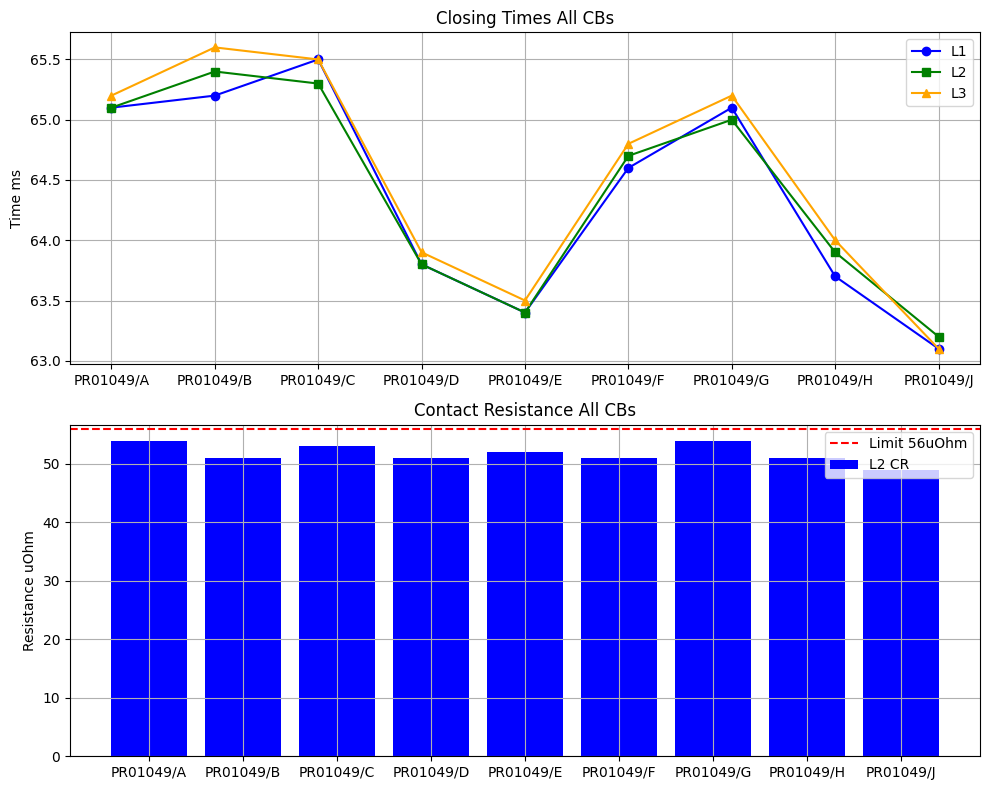

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8))

ax1.plot(df['CB_ Serial'], df['Close_L1_ms'],
         marker='o', label='L1', color='blue')
ax1.plot(df['CB_ Serial'], df['Close_L2_ms'],
         marker='s', label='L2', color='green')
ax1.plot(df['CB_ Serial'], df['Close_L3_ms'],
         marker='^', label='L3', color='orange')
ax1.set_title('Closing Times All CBs')
ax1.set_ylabel('Time ms')
ax1.legend()
ax1.grid(True)

ax2.bar(df['CB_ Serial'], df['CR_L2_uohm'],
        color='blue', label='L2 CR')
ax2.axhline(y=56, color='red',
            linestyle='--', label='Limit 56uOhm')
ax2.set_title('Contact Resistance All CBs')
ax2.set_ylabel('Resistance uOhm')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [21]:
print("=" * 50)
print("EVOLIS CB FINAL TEST SUMMARY")
print("=" * 50)
print("Project : Confidential")
print("Customer : Confidential Customer")
print("Engineer : Mohammed Azam Ali MIET")
print("Company : Schneider Electric Leeds")
print("=" * 50)
print("Total CBs Tested :", len(df))
print("Passed :", len(df))
print("Failed : 0")
print("-" * 50)
print("Avg Closing Time :", round(np.mean(df['Close_L1_ms']),2), "ms")
print("Avg Opening Time :", round(np.mean(df['Open_L1_ms']),2), "ms")
print("Highest CR :", np.max(df['CR_L2_uohm']), "uOhm")
print("CR Limit : 56 uOhm")
print("IR Result : All >1TOhm")
print("PD Result : All Pass")
print("=" * 50)
print("ALL 9 CIRCUIT BREAKERS PASSED!")
print("READY FOR DISPATCH TO CUSTOMER!")
print("=" * 50)

EVOLIS CB FINAL TEST SUMMARY
Project : Confidential
Customer : Confidential Customer
Engineer : Mohammed Azam Ali MIET
Company : Schneider Electric Leeds
Total CBs Tested : 9
Passed : 9
Failed : 0
--------------------------------------------------
Avg Closing Time : 64.39 ms
Avg Opening Time : 43.81 ms
Highest CR : 54 uOhm
CR Limit : 56 uOhm
IR Result : All >1TOhm
PD Result : All Pass
ALL 9 CIRCUIT BREAKERS PASSED!
READY FOR DISPATCH TO CUSTOMER!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print ("-"* 55)
print ("11 kV PACKAGE SUBSTATION  SAT ANALYSER")
print ("-"* 55)
print ("Client : ABU DHABI DISTRIBUTION COMPANY")
print("Location : Shila PU-2 Substation")
print("Company : ACECO, UAE")
print ("Date : 16-05-2018")
print ("="* 55)

print ("\n TRANSFORMER NAMEPLATE DETAILS")
print ("-" * 40)
print ("Make   : Saudi Transformers")
print ("Rating : 1500 KVA")
print (" Voltage : 11kV/415V")
print ("Vector group : Dyn11")
print ("Impedence : 5.72%")
print ("Cooling : ONAN")
print ("Weight : 5010 kg")

print ("\nRMU NAMEPLATE DETAILS")
print ("-" * 40)
print ("Make : Lucy Switchgear")
print ("Type : VRN2A")
print ("Rated Volateg : 12kV")
print ("Normal Current : 630")
print ("Insulation : SF6")
print (" Standard  : IEC 60129/62271 ")
print ("=" * 55)


-------------------------------------------------------
11 kV PACKAGE SUBSTATION  SAT ANALYSER
-------------------------------------------------------
Client : ABU DHABI DISTRIBUTION COMPANY
Location : Shila PU-2 Substation
Company : ACECO, UAE
Date : 16-05-2018

 TRANSFORMER NAMEPLATE DETAILS
----------------------------------------
Make   : Saudi Transformers
Rating : 1500 KVA
 Voltage : 11kV/415V
Vector group : Dyn11
Impedence : 5.72%
Cooling : ONAN
Weight : 5010 kg

RMU NAMEPLATE DETAILS
----------------------------------------
Make : Lucy Switchgear
Type : VRN2A
Rated Volateg : 12kV
Normal Current : 630
Insulation : SF6
 Standard  : IEC 60129/62271 


In [8]:
ir_data = {
    'Test' : ['HV to Earth', 'LV to HV', 'LV to Earth'],
    'Voltage_kV' : [5.0, 2.5, 1.0],
    'IR_15s_Gohm': [1.73, 3.50, 1.02],
    'IR_60s_Gohm': [2.73, 6.60, 2.53],
    'IR_120s_Gohm':[3.32, 8.42, 3.80],
    'PI_Ratio' : [1.44, 1.98, 2.67],
    'Limit_Gohm' : [1.0, 1.0, 1.0],
    'PI_Limit'   : [1.0, 1.0, 1.0],
  }

ir_df = pd.DataFrame(ir_data)

print ("INSULATION RESISTANCE TEST RESULTS")
print("-"*50)
print(ir_df.to_string(index=False))
print("-"*50)

for index, row in ir_df.iterrows():
    test = row['Test']
    ir = row['IR_120s_Gohm']
    pi = row['PI_Ratio']
    limit = row['Limit_Gohm']

    if ir < limit:
        print(f"FAIL: {test} IR {ir}GO below limit!")
    elif pi < 1:
        print(f"WARNING: {test} PI {pi} below limit!")
    else:
        print(f"PASS: {test} IR {ir}GO PI {pi}")
        print("-"*50)

INSULATION RESISTANCE TEST RESULTS
--------------------------------------------------
       Test  Voltage_kV  IR_15s_Gohm  IR_60s_Gohm  IR_120s_Gohm  PI_Ratio  Limit_Gohm  PI_Limit
HV to Earth         5.0         1.73         2.73          3.32      1.44         1.0       1.0
   LV to HV         2.5         3.50         6.60          8.42      1.98         1.0       1.0
LV to Earth         1.0         1.02         2.53          3.80      2.67         1.0       1.0
--------------------------------------------------
PASS: HV to Earth IR 3.32GO PI 1.44
--------------------------------------------------
PASS: LV to HV IR 8.42GO PI 1.98
--------------------------------------------------
PASS: LV to Earth IR 3.8GO PI 2.67
--------------------------------------------------


In [9]:
print("EARTHING TEST RESULTS")
print("-" * 40)

earth_data = {
    'Location' : ['Transformer Neutral', 'Transformer Body'],
    'Result_Ohm' : [2.73, 5.55],
    'Limit_Ohm' : [1.0, 10.0]
}

earth_df = pd.DataFrame(earth_data)
print(earth_df.to_string(index=False))
print("-" * 40)

for index, row in earth_df.iterrows():
    location = row['Location']
    result = row['Result_Ohm']
    limit = row['Limit_Ohm']

    if result > limit:
        print(f"SNAG: {location} {result} Ohm exceeds limit {limit} Ohm!")
    else:
        print(f"PASS: {location} {result} Ohm within limit {limit} Ohm")

print("-" * 40)
print("ACTION: Neutral earthing must be improved")
print("before substation energisation!")

EARTHING TEST RESULTS
----------------------------------------
           Location  Result_Ohm  Limit_Ohm
Transformer Neutral        2.73        1.0
   Transformer Body        5.55       10.0
----------------------------------------
SNAG: Transformer Neutral 2.73 Ohm exceeds limit 1.0 Ohm!
PASS: Transformer Body 5.55 Ohm within limit 10.0 Ohm
----------------------------------------
ACTION: Neutral earthing must be improved
before substation energisation!


In [10]:
print("RMU TEST RESULTS")
print("-" * 40)

rmu_data = {
    'Phase' : ['R', 'Y', 'B'],
    'IR_GΩ' : [319, 603, 917],
    'HV_mA' : [7.30, 7.30, 7.30],
    'CT_Ratio' : ['100/1', '100/1', '100/1'],
    'CT_Result' : ['Pass', 'Pass', 'Pass']
}

rmu_df = pd.DataFrame(rmu_data)
print(rmu_df.to_string(index=False))
print("-" * 40)

for index, row in rmu_df.iterrows():
    phase = row['Phase']
    ir = row['IR_GΩ']
    hv = row['HV_mA']

    if ir < 1:
        print(f"FAIL: Phase {phase} IR {ir}GO below limit!")
    elif hv > 10:
        print(f"FAIL: Phase {phase} HV current {hv}mA too high!")
    else:
        print(f"PASS: Phase {phase} IR {ir}GO HV {hv}mA")

print("-" * 40)

RMU TEST RESULTS
----------------------------------------
Phase  IR_GΩ  HV_mA CT_Ratio CT_Result
    R    319    7.3    100/1      Pass
    Y    603    7.3    100/1      Pass
    B    917    7.3    100/1      Pass
----------------------------------------
PASS: Phase R IR 319GO HV 7.3mA
PASS: Phase Y IR 603GO HV 7.3mA
PASS: Phase B IR 917GO HV 7.3mA
----------------------------------------


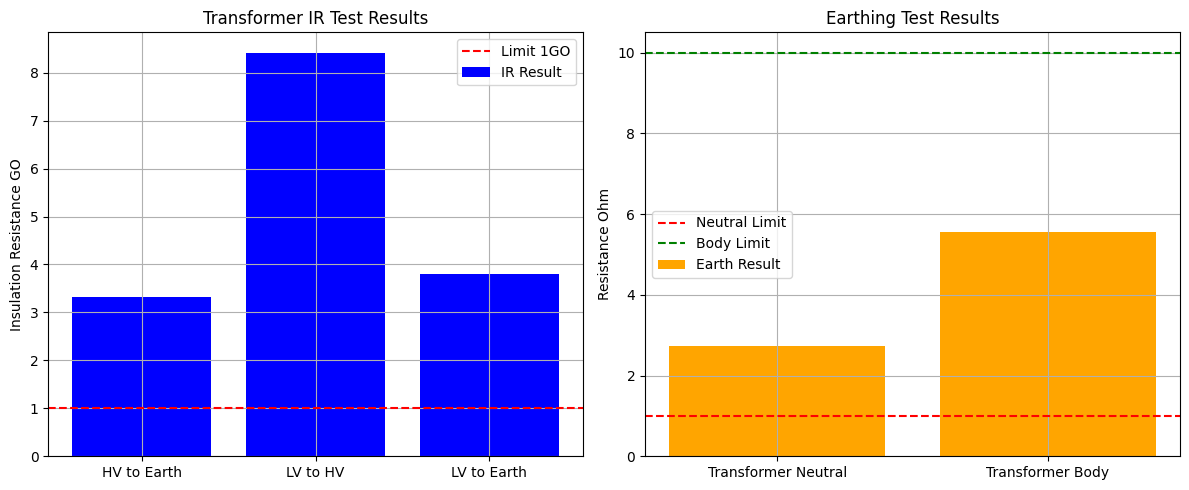

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.bar(ir_df['Test'], ir_df['IR_120s_Gohm'],
        color='blue', label='IR Result')
ax1.axhline(y=1.0, color='red',
            linestyle='--', label='Limit 1GO')
ax1.set_title('Transformer IR Test Results')
ax1.set_ylabel('Insulation Resistance GO')
ax1.legend()
ax1.grid(True)

ax2.bar(earth_df['Location'], earth_df['Result_Ohm'],
        color='orange', label='Earth Result')
ax2.axhline(y=1.0, color='red',
            linestyle='--', label='Neutral Limit')
ax2.axhline(y=10.0, color='green',
            linestyle='--', label='Body Limit')
ax2.set_title('Earthing Test Results')
ax2.set_ylabel('Resistance Ohm')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
print("=" * 55)
print(" FINAL SAT REPORT")
print(" 11kV PACKAGE SUBSTATION - SHILA PU-2")
print("=" * 55)
print("Client : Abu Dhabi Distribution Company")
print("Engineer : Mohammed Azam Ali MIET")
print("Company : ACECO")
print("=" * 55)

print("\nTEST SUMMARY:")
print("-" * 40)
print("Visual Inspection : PASS")
print("IR Test - Transformer : PASS")
print("IR Test - RMU : PASS")
print("HV Test - RMU : PASS")
print("CT Ratio Test : PASS")
print("Transformer Body Earth : PASS")
print("Neutral Earthing : SNAG")
print("-" * 40)

print("\nSNAG LIST:")
print("-" * 40)
print("1. Neutral earthing high - 2.73 Ohm")
print(" Limit : 1.0 Ohm")
print(" Action : Improve earthing before")
print(" energisation!")
print("-" * 40)

total_tests = 7
passed = 6
failed = 0
snags = 1

print(f"\nTotal Tests : {total_tests}")
print(f"Passed : {passed}")
print(f"Failed : {failed}")
print(f"Snags : {snags}")
print("-" * 40)

if failed > 0:
    print("OVERALL: FAIL - DO NOT ENERGISE!")
elif snags > 0:
    print("OVERALL: CONDITIONAL PASS")
    print("Resolve snags before energisation!")
else:
    print("OVERALL: PASS - READY TO ENERGISE!")

print("=" * 55)
print("Signed : Mohammed Azam Ali MIET")
print("Company: ACECO - Abu Dhabi UAE")
print("=" * 55)

 FINAL SAT REPORT
 11kV PACKAGE SUBSTATION - SHILA PU-2
Client : Abu Dhabi Distribution Company
Engineer : Mohammed Azam Ali MIET
Company : ACECO

TEST SUMMARY:
----------------------------------------
Visual Inspection : PASS
IR Test - Transformer : PASS
IR Test - RMU : PASS
HV Test - RMU : PASS
CT Ratio Test : PASS
Transformer Body Earth : PASS
Neutral Earthing : SNAG
----------------------------------------

SNAG LIST:
----------------------------------------
1. Neutral earthing high - 2.73 Ohm
 Limit : 1.0 Ohm
 Action : Improve earthing before
 energisation!
----------------------------------------

Total Tests : 7
Passed : 6
Failed : 0
Snags : 1
----------------------------------------
OVERALL: CONDITIONAL PASS
Resolve snags before energisation!
Signed : Mohammed Azam Ali MIET
Company: ACECO - Abu Dhabi UAE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')